# Assignment 01 - Vietnam House Price Intelligent System

**Formal problem statement:** Given a structured feature vector describing a Vietnamese house, predict its `Price` in **billion VND** for a previously unseen property.

This notebook follows the workflow of **Chapter 12 - Deploying Machine Learning Models** as closely as possible, adapted from a classification case study to a **regression** problem:

**Load data -> Clean data -> Examine/plot relationships -> Prepare features -> Evaluate algorithms -> Select the best model -> `fit()` the final model -> Save/load model -> Predict -> Deploy as an application.**

## 1. System and Problem Definition

The intelligent system receives house information from a user or dataset, converts the raw information into a numerical feature representation, applies preprocessing, and uses a trained regression model to predict house price.

**System path:**

`User / Environment -> Input -> Feature Representation -> Preprocessing -> ML Model -> Predicted Price`

The output can be used by a buyer, seller, or real-estate analyst as a reference price. The prediction is supportive, not a professional property valuation.

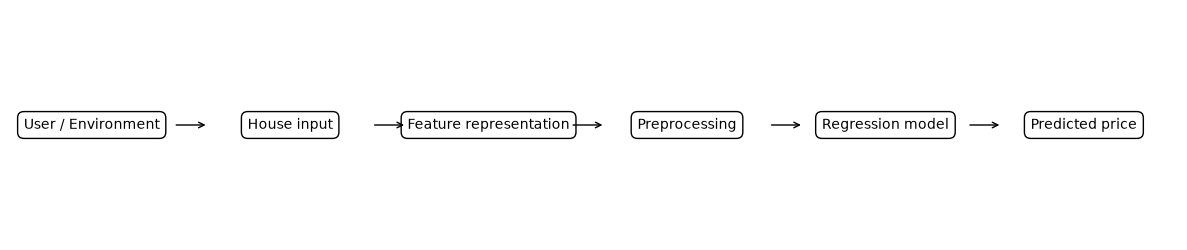

In [1]:
# Create the required system diagram using Python.
import os
import matplotlib.pyplot as plt

os.makedirs('figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 2.6))
ax.axis('off')
labels = [
    'User / Environment',
    'House input',
    'Feature representation',
    'Preprocessing',
    'Regression model',
    'Predicted price'
]
xs = [0.07, 0.24, 0.41, 0.58, 0.75, 0.92]
for x, label in zip(xs, labels):
    ax.text(x, 0.5, label, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.45', fc='white', ec='black'))
for x1, x2 in zip(xs[:-1], xs[1:]):
    ax.annotate('', xy=(x2-0.07, 0.5), xytext=(x1+0.07, 0.5),
                arrowprops=dict(arrowstyle='->'))
plt.tight_layout()
plt.savefig('figures/05_system_diagram.png', dpi=160, bbox_inches='tight')
plt.show()

## 2. Dataset Source

Dataset: **House Price Prediction Dataset Vietnam - 2024** (Kaggle), provided for this assignment as `gia_nha.csv`.

One observation is one real-estate listing. The target is `Price`, a numerical value measured in **billion VND**, therefore this is a **regression** task.

## 3. Loading the Data - Chapter 12 Pattern

Chapter 12 begins by loading a local CSV file with `pandas` and inspecting the DataFrame using `info()`. The same pattern is used here.

In [2]:
import re
import math
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

warnings.filterwarnings('ignore')

df = pd.read_csv('gia_nha.csv')
print('Shape:', df.shape)
df.info()
display(df.head())

Shape: (30229, 12)
<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 2.8 MB


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


## 4. Dataset Description and Feature/Target Analysis

The assignment requires identifying observations, features, target, feature types, and learning task before model training.

In [3]:
summary = pd.DataFrame({
    'Type': df.dtypes.astype(str),
    'Missing': df.isnull().sum(),
    'Unique': df.nunique(dropna=True)
})
display(summary)

print('\nTarget statistics:')
print(df['Price'].describe())
print('\nNumber of observations:', len(df))
print('Original number of columns:', df.shape[1])
print('Target: Price')
print('Task: Regression')

,Type,Missing,Unique
Address,str,0,10265
Area,float64,0,1512
Frontage,float64,11564,407
Access Road,float64,13297,140
House direction,str,21239,8
Balcony direction,str,24983,8
Floors,float64,3603,10
Bedrooms,float64,5162,9
Bathrooms,float64,7074,9
Legal status,str,4506,2



Target statistics:
count    30229.000000
mean         5.872078
std          2.211877
min          1.000000
25%          4.200000
50%          5.900000
75%          7.500000
max         11.500000
Name: Price, dtype: float64

Number of observations: 30229
Original number of columns: 12
Target: Price
Task: Regression


## 5. Cleaning the Data - Chapter 12 Pattern

Chapter 12 explicitly checks null values and invalid zero values before modeling. For this housing dataset, `Price` and `Area` must be positive. Missing values in other features are retained here and handled by the preprocessing step using the **training data only**.

In [4]:
print('Nulls')
print('=====')
print(df.isnull().sum())

print('\n0s')
print('==')
print(df.select_dtypes(include=np.number).eq(0).sum())

# Price and Area are essential and must be positive.
df = df[(df['Price'] > 0) & (df['Area'] > 0)].copy()
df.reset_index(drop=True, inplace=True)
print('\nShape after checking positive Price and Area:', df.shape)

Nulls
=====
Address                  0
Area                     0
Frontage             11564
Access Road          13297
House direction      21239
Balcony direction    24983
Floors                3603
Bedrooms              5162
Bathrooms             7074
Legal status          4506
Furniture state      14119
Price                    0
dtype: int64

0s
==
Area           0
Frontage       0
Access Road    0
Floors         0
Bedrooms       0
Bathrooms      0
Price          0
dtype: int64

Shape after checking positive Price and Area: (30229, 12)


## 6. Data Representation

The model does not receive a physical house directly. It receives selected information as a feature vector.

The full `Address` column has very high cardinality. Instead of encoding every full address directly, the last two comma-separated components are extracted as `Province` and `District`. This is a simple human-designed representation consistent with traditional machine learning.

**Numerical features:** `Area`, `Frontage`, `Access Road`, `Floors`, `Bedrooms`, `Bathrooms`  
**Categorical features:** `House direction`, `Balcony direction`, `Legal status`, `Furniture state`, `Province`, `District`

In [5]:
def extract_location(address):
    parts = [re.sub(r'[.\s]+$', '', p.strip()) for p in str(address).split(',')]
    province = parts[-1] if len(parts) >= 1 and parts[-1] and parts[-1].lower() != 'nan' else 'Unknown'
    district = parts[-2] if len(parts) >= 2 and parts[-2] else 'Unknown'
    return pd.Series([province, district])

df[['Province', 'District']] = df['Address'].apply(extract_location)

numeric_cols = ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']
categorical_cols = [
    'House direction', 'Balcony direction', 'Legal status',
    'Furniture state', 'Province', 'District'
]
feature_cols = numeric_cols + categorical_cols

X = df[feature_cols].copy()
y = df['Price'].copy()

feature_table = pd.DataFrame([
    ['Area', 'Numerical', 'Real value', 'House area (m²)'],
    ['Frontage', 'Numerical', 'Real value', 'Frontage width (m)'],
    ['Access Road', 'Numerical', 'Real value', 'Road/access width (m)'],
    ['Floors', 'Numerical', 'Real value', 'Number of floors'],
    ['Bedrooms', 'Numerical', 'Real value', 'Number of bedrooms'],
    ['Bathrooms', 'Numerical', 'Real value', 'Number of bathrooms'],
    ['House direction', 'Categorical', 'Ordinal encoded', 'House direction'],
    ['Balcony direction', 'Categorical', 'Ordinal encoded', 'Balcony direction'],
    ['Legal status', 'Categorical', 'Ordinal encoded', 'Legal status'],
    ['Furniture state', 'Categorical', 'Ordinal encoded', 'Furniture state'],
    ['Province', 'Categorical', 'Ordinal encoded', 'Province/city extracted from Address'],
    ['District', 'Categorical', 'Ordinal encoded', 'District extracted from Address'],
], columns=['Feature', 'Type', 'Representation', 'Meaning'])
display(feature_table)

,Feature,Type,Representation,Meaning
0,Area,Numerical,Real value,House area (m²)
1,Frontage,Numerical,Real value,Frontage width (m)
2,Access Road,Numerical,Real value,Road/access width (m)
3,Floors,Numerical,Real value,Number of floors
4,Bedrooms,Numerical,Real value,Number of bedrooms
5,Bathrooms,Numerical,Real value,Number of bathrooms
6,House direction,Categorical,Ordinal encoded,House direction
7,Balcony direction,Categorical,Ordinal encoded,Balcony direction
8,Legal status,Categorical,Ordinal encoded,Legal status
9,Furniture state,Categorical,Ordinal encoded,Furniture state


## 7. Exploratory Data Analysis - Three Distribution Charts

The teacher specifically requires **3 distribution charts**. The charts below are generated directly from `gia_nha.csv` when this notebook is run.

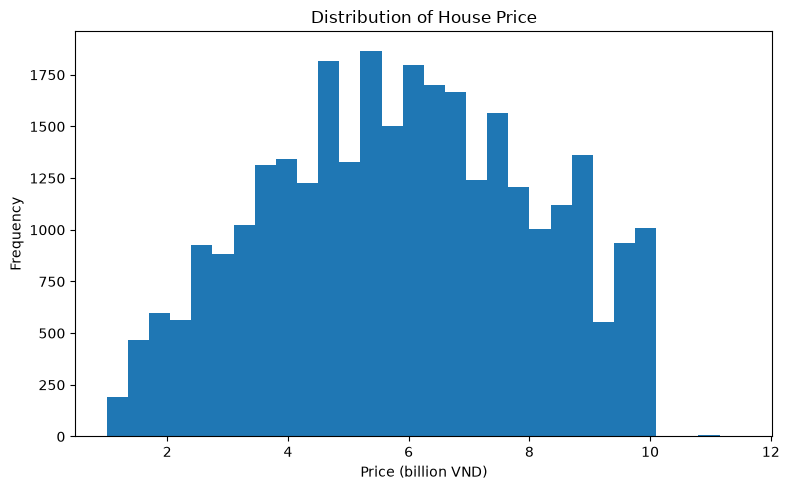

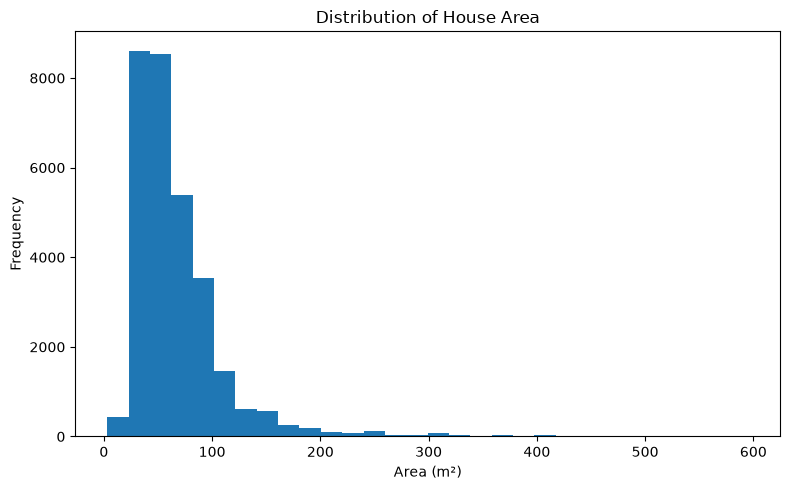

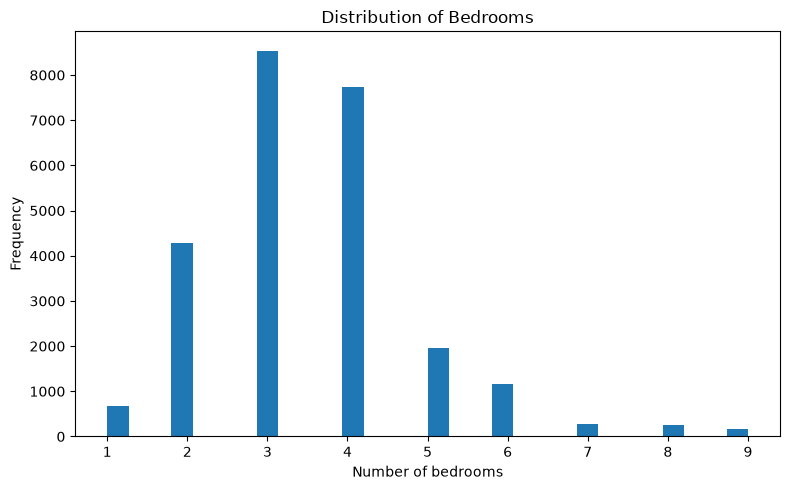

In [6]:
plot_specs = [
    ('Price', 'Distribution of House Price', 'Price (billion VND)', '01_price_distribution.png'),
    ('Area', 'Distribution of House Area', 'Area (m²)', '02_area_distribution.png'),
    ('Bedrooms', 'Distribution of Bedrooms', 'Number of bedrooms', '03_bedrooms_distribution.png')
]

for col, title, xlabel, filename in plot_specs:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig('figures/' + filename, dpi=160)
    plt.show()

## 8. Examining and Plotting Correlation Between Features - Chapter 12 Pattern

Like Chapter 12, `corr()` is used to inspect relationships between numerical columns. Categorical location variables cannot be judged by Pearson correlation directly, so they are evaluated later in the representation experiment.

                 Area  Frontage  Access Road    Floors  Bedrooms  Bathrooms  \
Area         1.000000  0.261108     0.269203 -0.359341  0.029541  -0.039367   
Frontage     0.261108  1.000000     0.142082 -0.039783  0.015079   0.013736   
Access Road  0.269203  0.142082     1.000000 -0.055556  0.073892   0.072499   
Floors      -0.359341 -0.039783    -0.055556  1.000000  0.498771   0.620851   
Bedrooms     0.029541  0.015079     0.073892  0.498771  1.000000   0.782130   
Bathrooms   -0.039367  0.013736     0.072499  0.620851  0.782130   1.000000   
Price        0.097593  0.047469     0.164280  0.331639  0.389432   0.434101   

                Price  
Area         0.097593  
Frontage     0.047469  
Access Road  0.164280  
Floors       0.331639  
Bedrooms     0.389432  
Bathrooms    0.434101  
Price        1.000000  


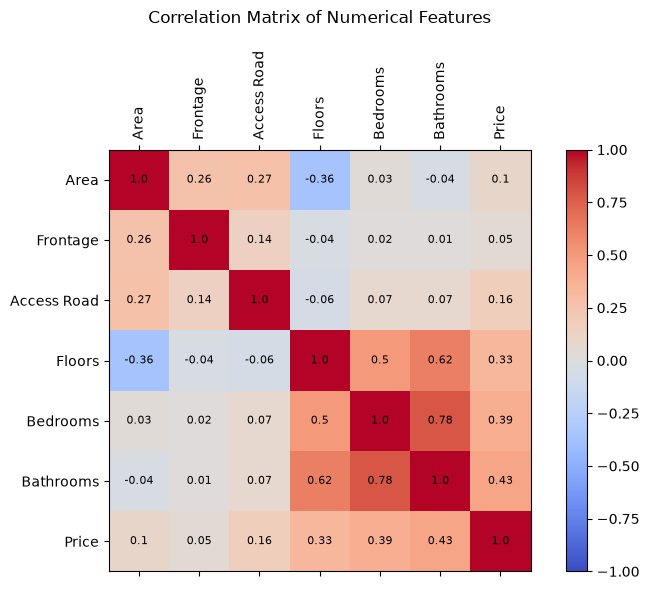


Correlation with Price:
Price          1.000000
Bathrooms      0.434101
Bedrooms       0.389432
Floors         0.331639
Access Road    0.164280
Area           0.097593
Frontage       0.047469
Name: Price, dtype: float64


In [7]:
correlation_cols = numeric_cols + ['Price']
corr = df[correlation_cols].corr()
print(corr)

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
fig.colorbar(cax)
ticks = np.arange(len(correlation_cols))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(correlation_cols, rotation=90)
ax.set_yticklabels(correlation_cols)
for i in range(len(correlation_cols)):
    for j in range(len(correlation_cols)):
        ax.text(j, i, round(corr.iloc[i, j], 2), ha='center', va='center', fontsize=8)
plt.title('Correlation Matrix of Numerical Features', pad=20)
plt.tight_layout()
plt.savefig('figures/04_correlation_matrix.png', dpi=160, bbox_inches='tight')
plt.show()

print('\nCorrelation with Price:')
print(corr['Price'].sort_values(ascending=False))

## 9. Train/Test Separation

The assignment requires separating training data from final evaluation data. We first keep **20% as an untouched test set**. The remaining 80% is split again into training and validation data for model comparison.

- Training: 64% of all observations
- Validation: 16%
- Final test: 20%

The final test set is not used to select the model.

In [8]:
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all, test_size=0.20, random_state=42
)

print('Training rows:', len(X_train))
print('Validation rows:', len(X_val))
print('Final test rows:', len(X_test))

Training rows: 19346
Validation rows: 4837
Final test rows: 6046


## 10. Preprocessing the Feature Representation

Preprocessing is **fit only on the training data**:

- Numerical missing values -> median
- Numerical features -> standardization
- Categorical missing values -> most frequent category
- Categorical features -> ordinal encoding (unknown category = -1)

After this step, every model receives exactly the same numerical matrix.

In [9]:
def make_preprocessor(cat_cols):
    numerical = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    categorical = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ])
    return ColumnTransformer([
        ('num', numerical, numeric_cols),
        ('cat', categorical, cat_cols)
    ])

preprocessor = make_preprocessor(categorical_cols)

# Fit preprocessing on TRAINING data only.
X_train_ready = preprocessor.fit_transform(X_train)
X_val_ready = preprocessor.transform(X_val)
X_test_ready = preprocessor.transform(X_test)

print('Encoded training shape:', X_train_ready.shape)

Encoded training shape: (19346, 12)


## 11. Evaluation Metrics

Five regression metrics are reported:

1. **MAE** - mean absolute error; lower is better.
2. **MSE** - mean squared error; lower is better.
3. **RMSE** - square root of MSE, in billion VND; lower is better.
4. **R²** - proportion of variance explained by the model; higher is better.
5. **MAPE** - mean absolute percentage error; lower is better.

In [10]:
def evaluate(y_true, prediction):
    mse = mean_squared_error(y_true, prediction)
    return {
        'MAE': mean_absolute_error(y_true, prediction),
        'MSE': mse,
        'RMSE': math.sqrt(mse),
        'R2': r2_score(y_true, prediction),
        'MAPE (%)': mean_absolute_percentage_error(y_true, prediction) * 100
    }

## 12. Baseline - First Reference Point

Before the learned models, a mean-price baseline is trained with `.fit()`. It predicts the mean training price for every validation example.

In [11]:
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train_ready, y_train)
baseline_prediction = baseline.predict(X_val_ready)
baseline_metrics = evaluate(y_val, baseline_prediction)
print(baseline_metrics)

{'MAE': 1.83436653972539, 'MSE': 4.827294775597199, 'RMSE': 2.1971105515192444, 'R2': -4.092793978394127e-06, 'MAPE (%)': 43.73229314047844}


## 13. Evaluating Five Traditional Machine-Learning Models

This section deliberately uses an explicit **`model.fit(X_train_ready, y_train)`** for every model, so the training step is clear and similar to the `fit()` examples throughout the book.

Models:
1. Linear Regression
2. Ridge Regression
3. Decision Tree Regressor
4. Random Forest Regressor
5. Extra Trees Regressor

In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10.0, solver='lsqr'),
    'Decision Tree': DecisionTreeRegressor(
        max_depth=15, min_samples_leaf=3, random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=50, max_depth=18, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    ),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=50, max_depth=18, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )
}

rows = [['Baseline Mean', *baseline_metrics.values()]]
for name, model in models.items():
    print('\nTraining:', name)
    model.fit(X_train_ready, y_train)          # EXPLICIT FIT
    prediction = model.predict(X_val_ready)
    metrics = evaluate(y_val, prediction)
    rows.append([name, *metrics.values()])
    print(metrics)

comparison = pd.DataFrame(
    rows,
    columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)']
)
comparison = comparison.sort_values('R2', ascending=False).reset_index(drop=True)
display(comparison)
comparison.to_csv('results/model_comparison.csv', index=False)


Training: Linear Regression
{'MAE': 1.574687482918364, 'MSE': 3.715792871434051, 'RMSE': 1.9276391963835067, 'R2': 0.23025042966243003, 'MAPE (%)': 35.8366221783601}

Training: Ridge Regression
{'MAE': 1.5758980920451053, 'MSE': 3.720487014362653, 'RMSE': 1.9288564006588602, 'R2': 0.2292780088016838, 'MAPE (%)': 35.87815020493238}

Training: Decision Tree
{'MAE': 1.2141225913385607, 'MSE': 2.681858480381284, 'RMSE': 1.6376380797909178, 'R2': 0.4444363600431379, 'MAPE (%)': 25.173432265060114}

Training: Random Forest
{'MAE': 1.047520816977496, 'MSE': 1.9424229708371599, 'RMSE': 1.3937083521444362, 'R2': 0.5976150181270223, 'MAPE (%)': 21.987073463730475}

Training: Extra Trees
{'MAE': 1.155786743377843, 'MSE': 2.2102394002902614, 'RMSE': 1.486687391582461, 'R2': 0.5421351814855074, 'MAPE (%)': 24.575734088950902}


,Model,MAE,MSE,RMSE,R2,MAPE (%)
0,Random Forest,1.047521,1.942423,1.393708,0.597615,21.987073
1,Extra Trees,1.155787,2.210239,1.486687,0.542135,24.575734
2,Decision Tree,1.214123,2.681858,1.637638,0.444436,25.173432
3,Linear Regression,1.574687,3.715793,1.927639,0.230250,35.836622
4,Ridge Regression,1.575898,3.720487,1.928856,0.229278,35.878150
5,Baseline Mean,1.834367,4.827295,2.197111,-0.000004,43.732293


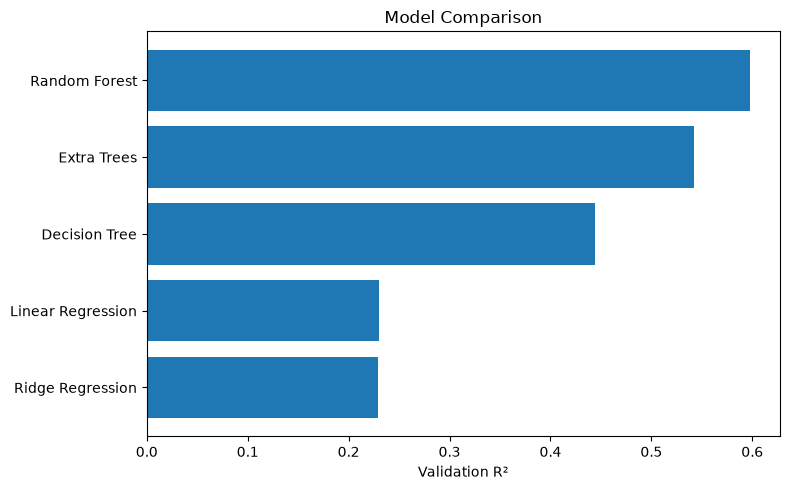

In [13]:
plot_df = comparison[comparison['Model'] != 'Baseline Mean'].sort_values('R2')
plt.figure(figsize=(8, 5))
plt.barh(plot_df['Model'], plot_df['R2'])
plt.xlabel('Validation R²')
plt.title('Model Comparison')
plt.tight_layout()
plt.savefig('figures/06_model_comparison.png', dpi=160)
plt.show()

## 14. Experiment 1 - Model Comparison

**Experimental question:** Under the same representation, preprocessing, training data, validation data, and five metrics, which model performs best?

The best model is selected by the highest validation **R²**, while MAE, RMSE, and MAPE are also checked to ensure that the result is consistent.

In [14]:
best_row = comparison[comparison['Model'] != 'Baseline Mean'].iloc[0]
best_model_name = best_row['Model']
print('Best validation model:', best_model_name)
print(best_row)

Best validation model: Random Forest
Model       Random Forest
MAE              1.047521
MSE              1.942423
RMSE             1.393708
R2               0.597615
MAPE (%)        21.987073
Name: 0, dtype: object


## 15. Experiment 2 - Hyperparameter Investigation

**Experimental question:** For Random Forest, how does `n_estimators` affect validation performance?

Only one meaningful hyperparameter is changed. Every candidate is trained using `.fit()` on the same training representation.

,n_estimators,MAE,MSE,RMSE,R2,MAPE (%)
0,10,1.081609,2.066456,1.437517,0.571921,22.678983
1,30,1.053224,1.964008,1.401431,0.593144,22.078962
2,50,1.047521,1.942423,1.393708,0.597615,21.987073


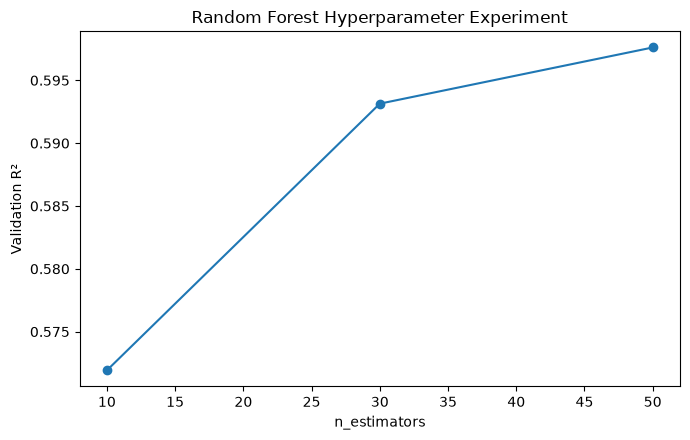

In [15]:
hyper_rows = []
for n in [10, 30, 50]:
    rf = RandomForestRegressor(
        n_estimators=n, max_depth=18, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )
    rf.fit(X_train_ready, y_train)             # EXPLICIT FIT
    pred = rf.predict(X_val_ready)
    m = evaluate(y_val, pred)
    hyper_rows.append([n, *m.values()])

hyper_df = pd.DataFrame(
    hyper_rows,
    columns=['n_estimators', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)']
)
display(hyper_df)
hyper_df.to_csv('results/hyperparameter_experiment.csv', index=False)

plt.figure(figsize=(7, 4.5))
plt.plot(hyper_df['n_estimators'], hyper_df['R2'], marker='o')
plt.xlabel('n_estimators')
plt.ylabel('Validation R²')
plt.title('Random Forest Hyperparameter Experiment')
plt.tight_layout()
plt.savefig('figures/07_hyperparameter.png', dpi=160)
plt.show()

## 16. Experiment 3 - Representation / Feature Investigation

**Experimental question:** Does location representation improve house-price prediction?

The same Random Forest settings are compared using:

- Representation A: original numerical/category features **without** `Province` and `District`
- Representation B: the full representation **with** `Province` and `District`

Only the representation changes.

,Representation,MAE,MSE,RMSE,R2,MAPE (%)
0,Without Province + District,1.396394,3.122580,1.767082,0.353138,31.139083
1,With Province + District,1.047521,1.942423,1.393708,0.597615,21.987073


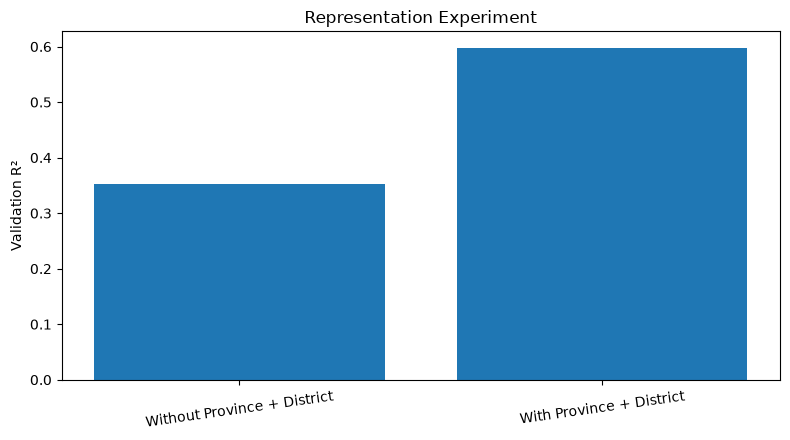

In [16]:
base_cat_cols = ['House direction', 'Balcony direction', 'Legal status', 'Furniture state']
representation_rows = []

for label, cat_cols in [
    ('Without Province + District', base_cat_cols),
    ('With Province + District', categorical_cols)
]:
    cols = numeric_cols + cat_cols
    pre = make_preprocessor(cat_cols)
    train_ready = pre.fit_transform(X_train[cols])
    val_ready = pre.transform(X_val[cols])

    rf = RandomForestRegressor(
        n_estimators=50, max_depth=18, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )
    rf.fit(train_ready, y_train)               # EXPLICIT FIT
    pred = rf.predict(val_ready)
    m = evaluate(y_val, pred)
    representation_rows.append([label, *m.values()])

representation_df = pd.DataFrame(
    representation_rows,
    columns=['Representation', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)']
)
display(representation_df)
representation_df.to_csv('results/representation_experiment.csv', index=False)

plt.figure(figsize=(8, 4.5))
plt.bar(representation_df['Representation'], representation_df['R2'])
plt.ylabel('Validation R²')
plt.title('Representation Experiment')
plt.xticks(rotation=8)
plt.tight_layout()
plt.savefig('figures/08_representation.png', dpi=160)
plt.show()

## 17. Selecting, Training, and Saving the Final Model - Chapter 12 Pattern

After model selection and controlled experiments are complete, the chosen model is trained again using the complete 80% training portion (`X_train_all`). The final 20% test set remains unseen until evaluation.

The preprocessing object and trained model are saved together so that new mobile/web inputs use exactly the same representation as training.

In [17]:
# Use Random Forest because the controlled experiments select it for this dataset.
final_preprocessor = make_preprocessor(categorical_cols)
X_train_all_ready = final_preprocessor.fit_transform(X_train_all)
X_test_final_ready = final_preprocessor.transform(X_test)

final_model = RandomForestRegressor(
    n_estimators=50, max_depth=18, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
final_model.fit(X_train_all_ready, y_train_all)    # FINAL EXPLICIT FIT

final_prediction = final_model.predict(X_test_final_ready)
final_metrics = evaluate(y_test, final_prediction)
print('Final unseen test metrics:')
print(final_metrics)

pd.DataFrame([final_metrics]).to_csv('results/final_test_metrics.csv', index=False)

bundle = {
    'preprocessor': final_preprocessor,
    'model': final_model,
    'feature_cols': feature_cols,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols
}
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print('Saved: house_price_model.pkl')

Final unseen test metrics:
{'MAE': 1.0553742117528313, 'MSE': 1.9951798296560115, 'RMSE': 1.4125083467562276, 'R2': 0.5908089750104905, 'MAPE (%)': 22.361456205316184}
Saved: house_price_model.pkl


## 18. Loading the Saved Model and Making Predictions - Chapter 12 Pattern

Like Chapter 12, the saved model is loaded from disk and used for new predictions. Three demonstration cases are required by Assignment 01.

In [18]:
with open('house_price_model.pkl', 'rb') as f:
    loaded_bundle = pickle.load(f)

examples = pd.DataFrame([
    {
        'Area': 50, 'Frontage': 5, 'Access Road': 6, 'Floors': 4,
        'Bedrooms': 4, 'Bathrooms': 3,
        'House direction': 'Tây', 'Balcony direction': 'Tây',
        'Legal status': 'Have certificate', 'Furniture state': 'Basic',
        'Province': 'Hồ Chí Minh', 'District': 'Bình Tân'
    },
    {
        'Area': 80, 'Frontage': 5, 'Access Road': 10, 'Floors': 5,
        'Bedrooms': 5, 'Bathrooms': 4,
        'House direction': 'Đông - Nam', 'Balcony direction': 'Đông - Nam',
        'Legal status': 'Have certificate', 'Furniture state': 'Full',
        'Province': 'Hà Nội', 'District': 'Cầu Giấy'
    },
    {
        'Area': 120, 'Frontage': 7, 'Access Road': 15, 'Floors': 3,
        'Bedrooms': 4, 'Bathrooms': 4,
        'House direction': 'Nam', 'Balcony direction': 'Nam',
        'Legal status': 'Sale contract', 'Furniture state': 'Basic',
        'Province': 'Đà Nẵng', 'District': 'Ngũ Hành Sơn'
    }
])

example_ready = loaded_bundle['preprocessor'].transform(
    examples[loaded_bundle['feature_cols']]
)
example_prices = loaded_bundle['model'].predict(example_ready)
examples['Predicted Price (billion VND)'] = example_prices

display(examples)
examples.to_csv('results/demo_predictions.csv', index=False)

,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,House direction,Balcony direction,Legal status,Furniture state,Province,District,Predicted Price (billion VND)
0,50,5,6,4,4,3,Tây,Tây,Have certificate,Basic,Hồ Chí Minh,Bình Tân,5.718452
1,80,5,10,5,5,4,Đông - Nam,Đông - Nam,Have certificate,Full,Hà Nội,Cầu Giấy,8.425941
2,120,7,15,3,4,4,Nam,Nam,Sale contract,Basic,Đà Nẵng,Ngũ Hành Sơn,6.825210


## 19. Intelligent Application / Mobile Deployment

Chapter 12 deploys the trained model through a Flask REST API so that a front-end client can send input and receive a prediction. This project follows the same architecture in `app.py`.

For the simplest free mobile demonstration:

1. Run `python app.py` on the laptop.
2. Connect the laptop and phone to the same Wi-Fi.
3. Find the laptop IPv4 address with `ipconfig`.
4. Open `http://<LAPTOP_IP>:5000` in the phone browser.
5. Enter house information and press **Predict**.

This provides a mobile user interface while the Python model runs on the laptop/server.

## 20. Model Understanding

### Linear Regression
- **Input representation:** encoded numerical feature matrix.
- **Relationship learned:** linear relationship between features and price.
- **Learned parameters:** coefficients and intercept.
- **Criterion:** minimizes squared prediction error.
- **Assumption:** approximately linear additive effects.
- **Strength:** simple, fast, interpretable.
- **Weakness:** cannot naturally capture complex non-linear interactions.

### Ridge Regression
- **Input representation:** same encoded numerical matrix.
- **Relationship learned:** linear relationship with L2 regularization.
- **Learned parameters:** coefficients and intercept.
- **Criterion:** squared error plus L2 penalty.
- **Assumption:** mainly linear additive effects.
- **Strength:** more stable than ordinary linear regression when features are correlated.
- **Weakness:** still limited for strong non-linear effects.

### Decision Tree Regressor
- **Input representation:** same encoded numerical matrix.
- **Relationship learned:** recursive feature-space splits that reduce prediction error.
- **Learned structure:** tree nodes, thresholds, and leaf predictions.
- **Criterion:** squared-error reduction at splits.
- **Assumption:** few distributional assumptions.
- **Strength:** captures non-linearity and feature interactions.
- **Weakness:** one tree can overfit and be unstable.

### Random Forest Regressor
- **Input representation:** same encoded numerical matrix.
- **Relationship learned:** ensemble of many decision trees.
- **Learned structure:** many randomized trees and their split rules.
- **Criterion:** each tree uses squared-error reduction; predictions are averaged.
- **Assumption:** few distributional assumptions.
- **Strength:** strong non-linear performance and lower variance than a single tree.
- **Weakness:** larger/slower and less interpretable than linear models.

### Extra Trees Regressor
- **Input representation:** same encoded numerical matrix.
- **Relationship learned:** ensemble of many highly randomized decision trees.
- **Learned structure:** many trees with randomized split candidates and leaf predictions.
- **Criterion:** squared-error reduction within each tree; predictions are averaged.
- **Assumption:** few distributional assumptions.
- **Strength:** captures non-linearity and often trains quickly because splits are highly randomized.
- **Weakness:** less interpretable than linear models and can still require many trees.

## 21. Reflection - What Makes This an Intelligent System?

1. **Information received:** physical house attributes, categorical status/direction information, and location derived from address.
2. **Internal representation:** imputed/scaled numerical values plus ordinal-encoded categorical values.
3. **What is learned:** statistical relationships between the feature representation and observed house prices.
4. **Prediction/decision:** estimated price in billion VND for a new property.
5. **Why unseen inputs can be handled:** preprocessing applies the same learned transformation and the trained model generalizes from examples.
6. **Intelligent part:** learning a predictive mapping from examples rather than using hand-written price rules.
7. **Limitations:** dataset coverage, noisy listing prices, simplified address parsing, missing features such as exact coordinates and market time effects.

### Reflection on representation
The feature vector preserves major structural and location information, but it loses fine-grained spatial relationships and context. The same task could also be represented with geospatial coordinates, a graph of neighborhoods, text embeddings of full addresses/listing descriptions, or images. Changing representation could allow different learning methods and potentially improve performance.

## 22. Conclusion

The project follows the course progression **Understand -> Represent -> Learn -> Experiment -> Apply**. It loads a real structured dataset, constructs a feature representation, trains a baseline and five traditional machine-learning models using explicit `.fit()`, evaluates them with five regression metrics, performs the three controlled experiments required by Assignment 01, selects a final model, saves/loads it, demonstrates three unseen inputs, and exposes the trained system through a mobile-friendly Flask application.